In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
K = 252

**Chargement des prix**

In [25]:
prices = pd.read_csv("df_train.csv", sep=";", index_col=0)

**Visualitation des données**

In [26]:
prices.head(10)

,Asset1,Asset2,Asset3,Asset4,Asset5,Asset6,Asset7,Asset8,Asset9,Asset10,Asset11,Asset12,Asset13,Asset14,Asset15
0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
1,100.08,100.36,99.39,100.85,100.93,99.99,100.51,100.46,100.45,100.61,100.27,100.61,98.49,98.95,100.23
2,100.00,99.84,99.31,100.47,100.55,98.95,100.91,101.05,100.05,99.69,100.11,100.90,98.29,99.51,100.88
3,102.34,101.17,101.96,101.05,102.69,101.15,101.41,100.35,100.75,101.78,101.44,102.88,97.77,101.50,100.18
4,95.55,96.72,96.15,98.21,95.56,97.04,101.21,99.41,98.10,99.31,97.80,94.61,102.33,96.50,100.22
5,93.39,95.10,95.12,96.78,92.37,94.83,100.56,98.58,97.52,97.81,96.03,92.85,102.52,93.84,102.84
6,94.88,97.11,96.51,98.41,95.43,97.18,100.58,99.44,99.77,99.04,97.74,94.20,101.96,96.92,103.03
7,97.12,99.09,98.09,99.26,98.12,99.22,101.91,100.38,101.47,100.79,99.40,96.65,102.63,101.03,102.48
8,99.19,102.11,98.84,100.53,99.63,95.90,102.70,100.36,102.88,102.16,100.75,97.62,102.20,97.89,101.99
9,100.03,102.14,98.11,100.83,98.98,96.30,102.41,99.76,102.99,101.50,100.95,98.46,103.62,99.23,102.19


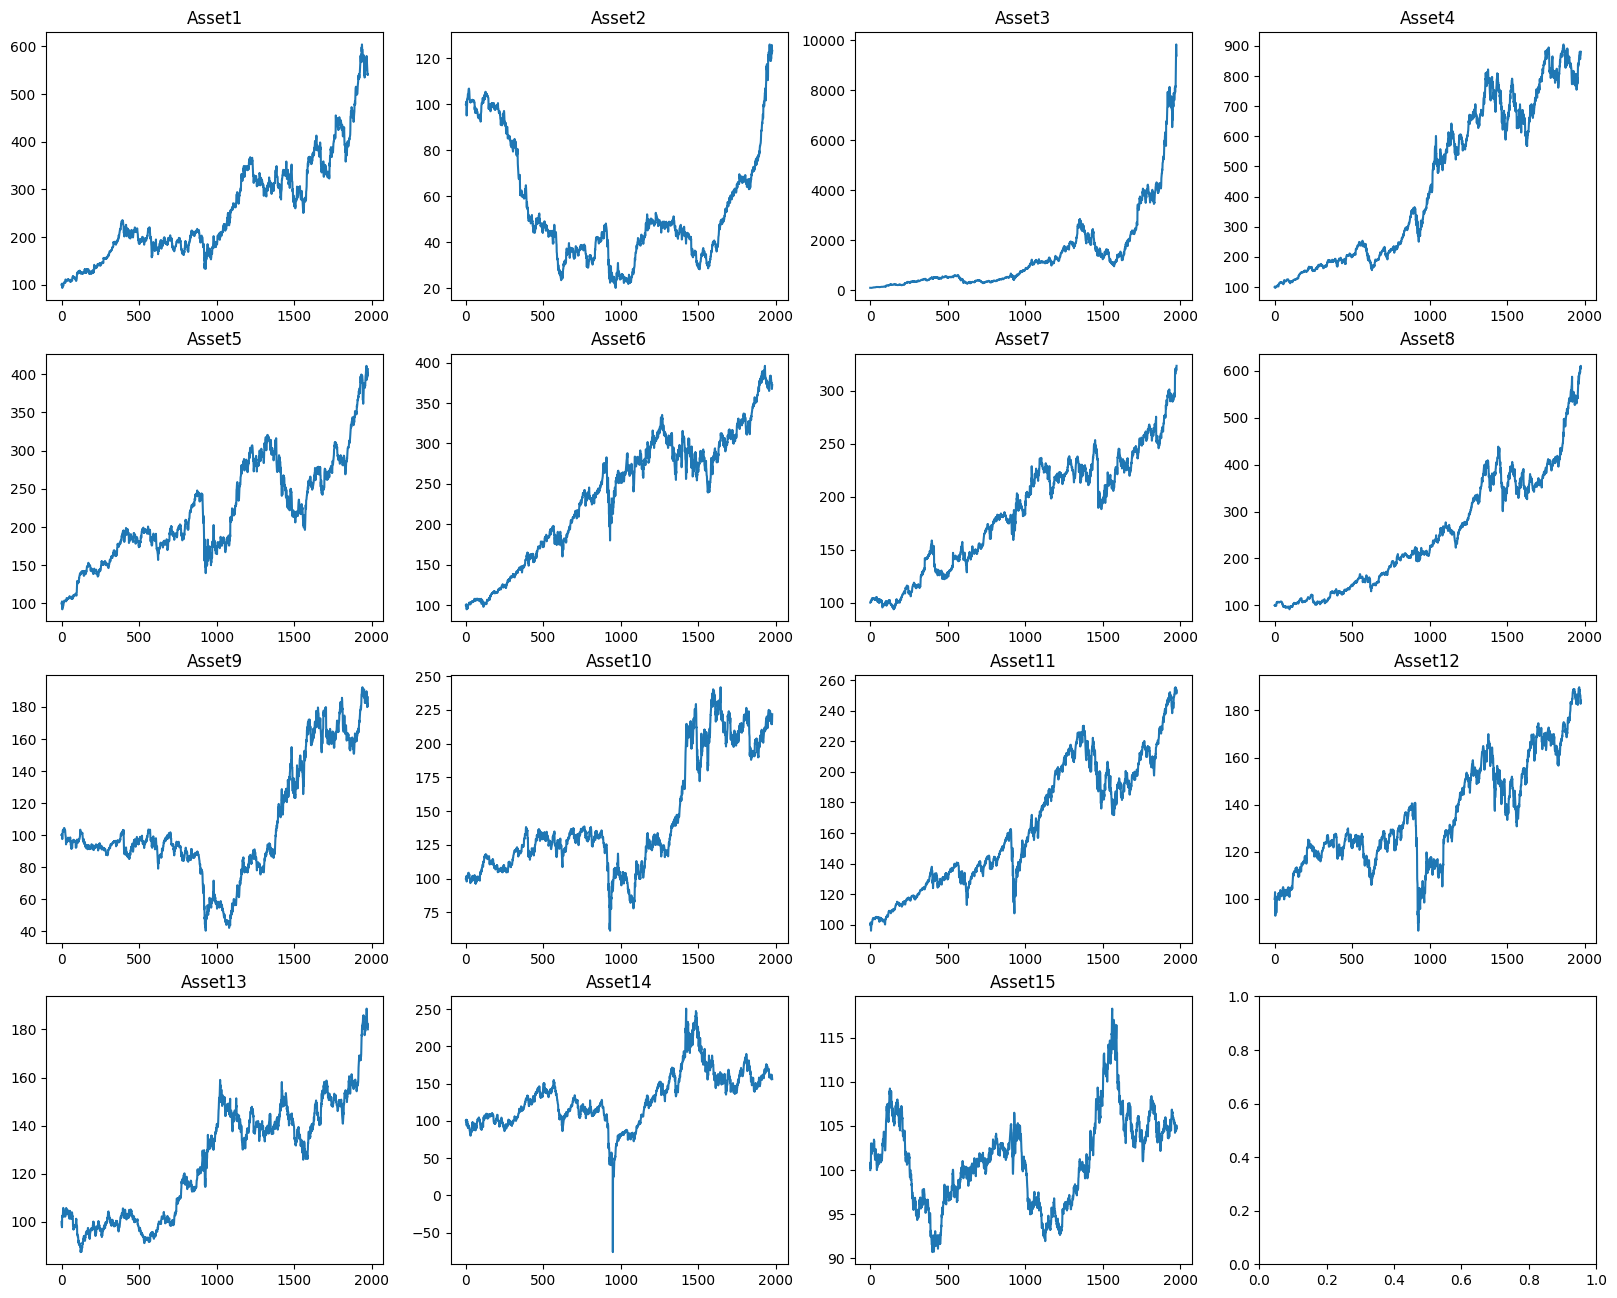

In [27]:
fig, ax = plt.subplots(4,4, figsize=(20,16))
j,k = 0,0
for i,asset in enumerate(prices.columns):
    ax[j,k].plot(prices[asset])
    ax[j,k].set_title(asset)
    if k < 3:
        k+=1
    else:
        k=0
        j+=1

**Quelques fonctions de base**

In [28]:
def normalize_price(serie):
    '''
    -serie (pd.Serie) : série de prix
    Normalise la série avec le prix à t_0 = 100
    '''
    s = serie/serie.shift(1)
    s.iloc[0] = 100
    return s.cumprod()

def get_returns(df):
    '''
    -df (pd.DataFrame ou pd.Series) : dataframe ou série des prix
    Renvoie les returns
    '''
    return (df/df.shift(1)).dropna()

def get_cagr(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Cumulative Annual Growth Return
    '''
    return round(float(((serie.iloc[-1]/serie.iloc[0])**(1/(len(serie)/252))) - 1), 4)

def get_vol(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Annualized Volatility
    '''
    return round(float(get_returns(serie).std() * np.sqrt(252)), 4)

def get_sr(serie, r=0.0):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -r (float) : taux d'intérêt (à 0 pour le projet)
    Annualized Sharpe Ratio
    '''
    return round(float((get_cagr(serie) - r) / get_vol(serie)), 4)

def get_calmar(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Calmar Ratio
    '''
    return round(get_cagr(serie)/get_mdd(serie), 4)

def get_mdd(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Max Drawdown
    '''
    running_max = np.maximum.accumulate(serie)
    drawdowns   = (serie - running_max) / running_max
    trough_idx  = int(np.argmin(drawdowns))
    mdd         = -drawdowns.iloc[trough_idx]
    return round(float(mdd), 4)

def get_corr(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Correlation
    '''
    return round(float(np.corrcoef(get_returns(serie), get_returns(benchmark))[0,1]), 4)

def overall_score(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Personnalized selection score
    '''
    return round((0.5*get_sr(serie) + 0.5*get_calmar(serie))/get_corr(serie, benchmark),4)

def compute_metrics(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Compute all metrics
    '''
    print(f"CAGR : {round(get_cagr(serie) * 100, 4)} %")
    print(f"Annualized Vol : {round(get_vol(serie)* 100, 4)} %")
    print(f"Sharpe Ratio : {round(get_sr(serie), 4)}")
    print(f"Calmar Ratio : {round(get_calmar(serie), 4)}")
    print(f"Max Drawdown : {round(get_mdd(serie)*100,4)} %")
    print(f"Corr-bench : {round(float(get_corr(serie, benchmark)), 4)}")
    print(f"Overall score : {overall_score(serie, benchmark)}")

#### Fonction à compléter
La fonction doit prendre en entrée un dataframe de taille 252 (moins de données pourront être utilisées dans la fonction si nécessaire) et renvoyer un vecteur (np.array, shape (15,)) de taille 15 comprenant les poids des asset 1 à 15. Il y a deux contraintes sur le vecteur :

- Les poids sont positifs.

- La somme des poids est égale ou inférieure à 1


In [29]:
def compute_weights(df):

    prices = df.copy()

    returns = prices.pct_change().dropna()

    lookback = min(60, len(prices)-1)

    # Momentum sur 60 jours
    momentum = prices.iloc[-1] / prices.iloc[-lookback] - 1

    # On garde seulement les momentum positifs
    momentum = momentum[momentum > 0]

    if len(momentum) == 0:
        return np.zeros(len(df.columns))

    # Top 5 actifs
    top_assets = momentum.nlargest(min(5, len(momentum))).index

    # Volatilité
    vol = returns[top_assets].std()

    # Risk parity
    inv_vol = 1 / (vol + 1e-8)

    weights = inv_vol / inv_vol.sum()

    final_weights = pd.Series(0.0, index=df.columns)

    final_weights[top_assets] = weights

    return final_weights.values

#### Benchmark Simple - Equally weighted
Une méthode simple de répartition des poids serait de répartir la valeur du portefeuille de manière équipondérée

In [30]:
eq_weighted_portfolio = normalize_price(((prices*1/15).sum(axis=1)).iloc[K:])

**Fonction permettant de valider les poids**

In [31]:
def check_weights(w):
    '''
    -w (np.array, shape : (15,)) : Vecteur des poids
    Renvoie False si les poids ne respectent pas les contraintes
    '''
    if round(w.sum(), 3)<=1 and (w<0).sum()==0:
        return True
    else:
        print("Poids négatifs ou somme supérieure à 1")
        print(f"Poids {w}")
        print(f"Somme : {w.sum()}")
        return False

**Chargement des autres benchmark**

In [32]:
df_benchmark = pd.read_csv("df_benchmark.csv", sep=";", index_col=0)
secret_bench = normalize_price(df_benchmark["Secret"])
sp500 = normalize_price(df_benchmark["SP500"])

**Backtest la stratégie**

In [33]:
def backtest():
    #Calculate Weights
    weights_t = []
    for i in range(len(prices)-K+1):
        w = compute_weights(prices.iloc[i:i+K])
        if check_weights(w):
            weights_t.append(w)
        else:
            break

    #Calculate portfolio value and returns
    pr = (np.array(weights_t)[1:-1] * get_returns(prices).iloc[K:]).sum(axis=1)
    portfolio = [100]
    for i in range(len(pr)):
        portfolio.append(pr.iloc[i]*portfolio[-1])
    portfolio = pd.Series(portfolio)
    portfolio.index = sp500.index

    print("==========PORTFOLIO===========")
    compute_metrics(portfolio, sp500)
    print("==========S&P500==============")
    compute_metrics(sp500, sp500)
    print("==========EQ-WEIGHTED=========")
    compute_metrics(eq_weighted_portfolio, sp500)
    print("======SECRET-BENCHMARK========")
    compute_metrics(secret_bench, sp500)

    plt.figure(figsize=(20,12))
    plt.plot(portfolio)
    plt.plot(sp500)
    plt.plot(eq_weighted_portfolio)
    plt.plot(secret_bench)
    plt.legend(["Portfolio", "S&P500", "Eq-Weighted", "Secret"])

    return portfolio




==========PORTFOLIO===========
CAGR : 25.75 %
Annualized Vol : 16.92 %
Sharpe Ratio : 1.5219
Calmar Ratio : 0.907
Max Drawdown : 28.39 %
Corr-bench : 0.6029
Overall score : 2.0143
==========S&P500==============
CAGR : 11.94 %
Annualized Vol : 19.6 %
Sharpe Ratio : 0.6092
Calmar Ratio : 0.352
Max Drawdown : 33.92 %
Corr-bench : 1.0
Overall score : 0.4806
==========EQ-WEIGHTED=========
CAGR : 33.58 %
Annualized Vol : 25.45 %
Sharpe Ratio : 1.3194
Calmar Ratio : 0.951
Max Drawdown : 35.31 %
Corr-bench : 0.8547
Overall score : 1.3282
======SECRET-BENCHMARK========
CAGR : 13.43 %
Annualized Vol : 13.37 %
Sharpe Ratio : 1.0045
Calmar Ratio : 0.6025
Max Drawdown : 22.29 %
Corr-bench : 0.7172
Overall score : 1.1203


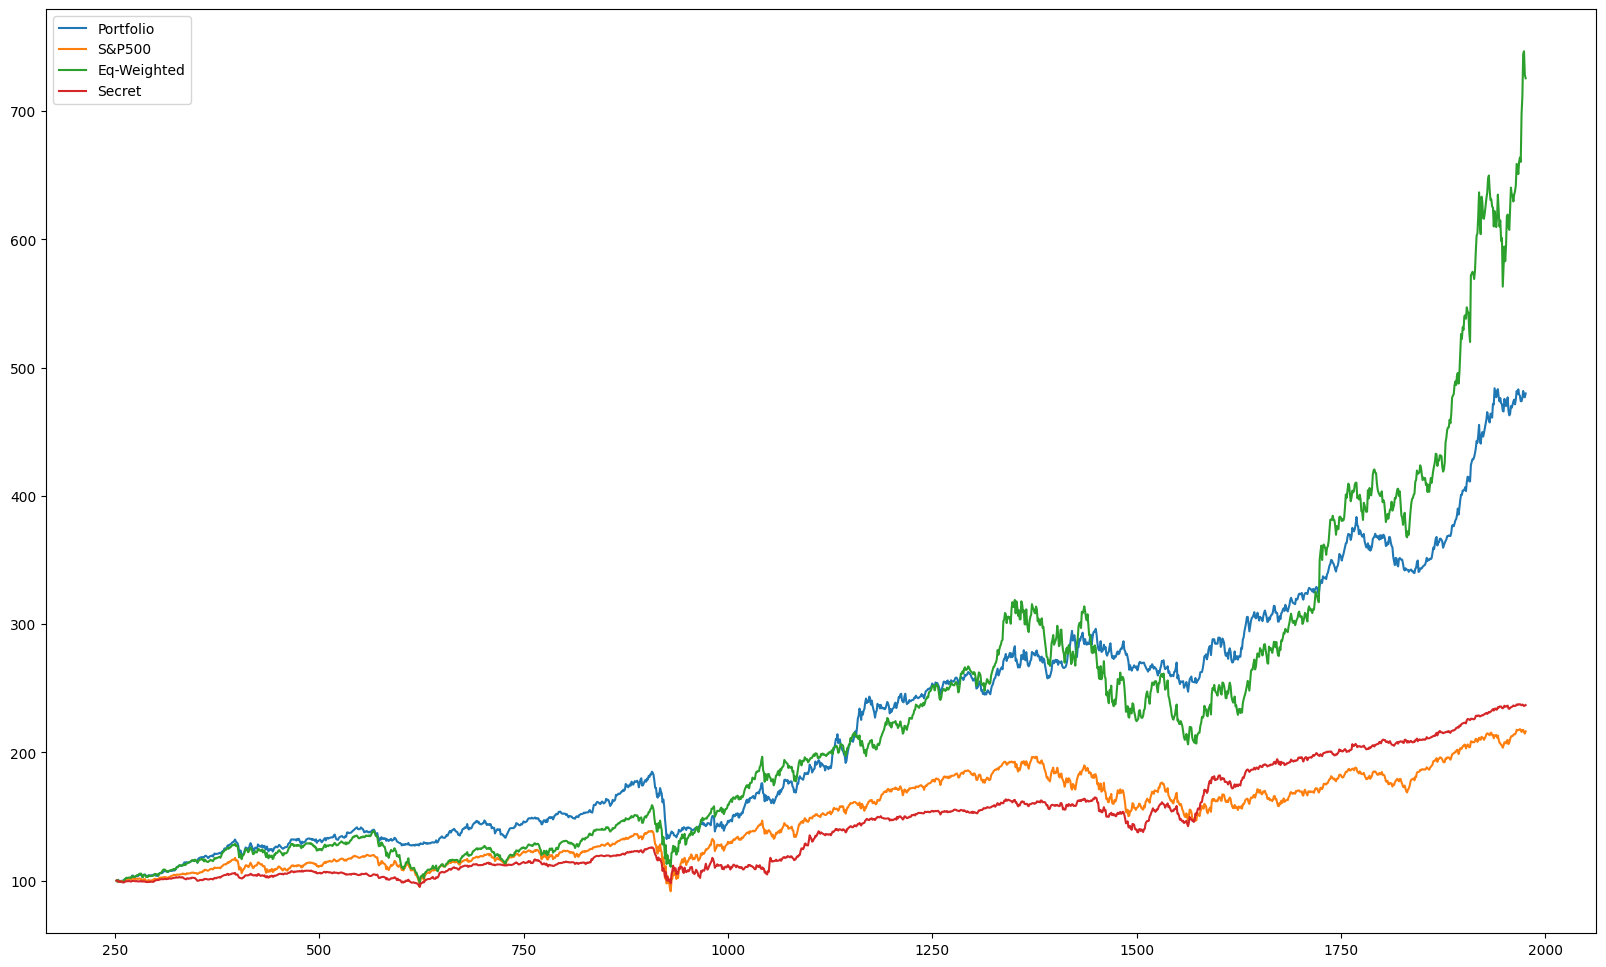

In [38]:
strat1 = backtest()
